<a href="https://colab.research.google.com/github/bogdangit-art/task_modul_4/blob/main/notebooks/data_cleaning_task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##In this notebook i will clean the dataset provided in the task and choose a machine learning model.

##1. Loading python libraries.

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

##2. Load Data.

In [46]:
# load dataset from GitHub
url = "https://raw.githubusercontent.com/bogdangit-art/task_modul_4/main/data/products.csv"
df = pd.read_csv(url)

print(f"Number of rows: {len(df)}")
print(f"Number of columns: {len(df.columns)}")

print("\nFirst 5 rows:")
print(df.head())

print("\nOriginal columns:")
print(df.columns.tolist())

Number of rows: 35311
Number of columns: 8

First 5 rows:
   product ID                                      Product Title  Merchant ID  \
0           1                    apple iphone 8 plus 64gb silver            1   
1           2                apple iphone 8 plus 64 gb spacegrau            2   
2           3  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...            3   
3           4                apple iphone 8 plus 64gb space grey            4   
4           5  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...            5   

   Category Label _Product Code  Number_of_Views  Merchant Rating  \
0   Mobile Phones    QA-2276-XC            860.0              2.5   
1   Mobile Phones    KA-2501-QO           3772.0              4.8   
2   Mobile Phones    FP-8086-IE           3092.0              3.9   
3   Mobile Phones    YI-0086-US            466.0              3.4   
4   Mobile Phones    NZ-3586-WP           4426.0              1.6   

   Listing Date    
0       5/10/2024  


##3. Cleaning column names.

In [47]:
# Remove unnecessary spaces from column names
df.columns = df.columns.str.strip()

print("Cleaned columns:")
print(df.columns.tolist())

Cleaned columns:
['product ID', 'Product Title', 'Merchant ID', 'Category Label', '_Product Code', 'Number_of_Views', 'Merchant Rating', 'Listing Date']


##4. Basic data information.

In [48]:
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Data types:
product ID           int64
Product Title       object
Merchant ID          int64
Category Label      object
_Product Code       object
Number_of_Views    float64
Merchant Rating    float64
Listing Date        object
dtype: object

Missing values:
product ID           0
Product Title      172
Merchant ID          0
Category Label      44
_Product Code       95
Number_of_Views     14
Merchant Rating    170
Listing Date        59
dtype: int64

Number of duplicate rows:
0


##5. Cleaning product title column.

In [49]:
# Convert Product Title to string
df["Product Title"] = df["Product Title"].astype("string")

# Remove leading/trailing spaces
df["Product Title"] = df["Product Title"].str.strip()

# Replace multiple spaces with a single space
df["Product Title"] = df["Product Title"].str.replace(
    r"\s+",
    " ",
    regex=True
)

# Remove rows where Product Title is missing
df = df.dropna(subset=["Product Title"])

# Remove empty titles
df = df[df["Product Title"] != ""]

print(f"Rows after Product Title cleaning: {len(df)}")

Rows after Product Title cleaning: 35139


##6. Cleaning category label column.

In [50]:
# Convert category to string
df["Category Label"] = df["Category Label"].astype("string")

# Remove leading/trailing spaces
df["Category Label"] = df["Category Label"].str.strip()

# Remove rows where the target category is missing
df = df.dropna(subset=["Category Label"])

# Remove empty categories
df = df[df["Category Label"] != ""]

print("Categories before checking:")
print(df["Category Label"].value_counts())

Categories before checking:
Category Label
Fridge Freezers     5470
Washing Machines    4015
Mobile Phones       4002
CPUs                3747
TVs                 3541
Fridges             3436
Dishwashers         3405
Digital Cameras     2689
Microwaves          2328
Freezers            2201
fridge               123
CPU                   84
Mobile Phone          55
Name: count, dtype: Int64


##7. Standardizing category label.

In [51]:
category_mapping = {
    "CPU": "CPUs",
    "Mobile Phone": "Mobile Phones",
    "fridge": "Fridges"
}

df["Category Label"] = df["Category Label"].replace(category_mapping)

print("\nCategories after standardization:")
print(df["Category Label"].value_counts())


Categories after standardization:
Category Label
Fridge Freezers     5470
Mobile Phones       4057
Washing Machines    4015
CPUs                3831
Fridges             3559
TVs                 3541
Dishwashers         3405
Digital Cameras     2689
Microwaves          2328
Freezers            2201
Name: count, dtype: Int64


##8. Duplicate removal.

In [52]:
print("7. REMOVING DUPLICATES")


before_duplicates = len(df)

df = df.drop_duplicates()

after_duplicates = len(df)

print(f"Rows before removing duplicates: {before_duplicates}")
print(f"Rows after removing duplicates:  {after_duplicates}")
print(f"Duplicates removed:              {before_duplicates - after_duplicates}")

7. REMOVING DUPLICATES
Rows before removing duplicates: 35096
Rows after removing duplicates:  35096
Duplicates removed:              0


##9. Dataset summary after cleaning.

In [53]:
print(f"Final number of rows: {len(df)}")
print(f"Final number of columns: {len(df.columns)}")

print("\nRemaining missing values:")
print(df.isnull().sum())

print("\nCategory distribution:")
print(df["Category Label"].value_counts())

Final number of rows: 35096
Final number of columns: 8

Remaining missing values:
product ID           0
Product Title        0
Merchant ID          0
Category Label       0
_Product Code       94
Number_of_Views     14
Merchant Rating    170
Listing Date        58
dtype: int64

Category distribution:
Category Label
Fridge Freezers     5470
Mobile Phones       4057
Washing Machines    4015
CPUs                3831
Fridges             3559
TVs                 3541
Dishwashers         3405
Digital Cameras     2689
Microwaves          2328
Freezers            2201
Name: count, dtype: Int64


##10. Vizualysing category distribution

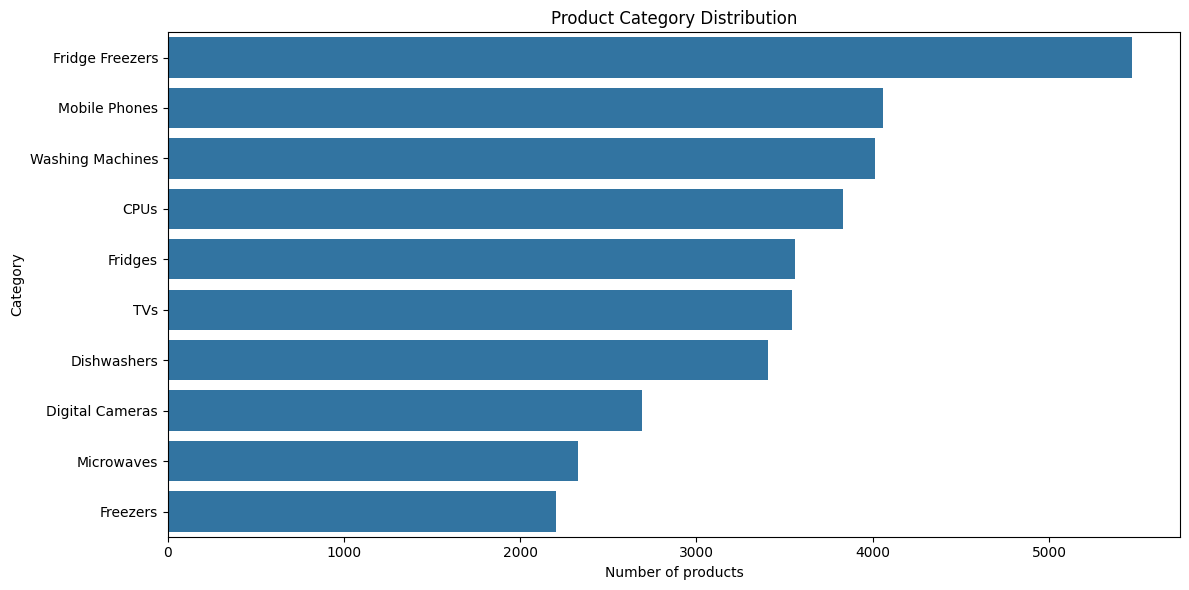

In [54]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    y="Category Label",
    order=df["Category Label"].value_counts().index
)

plt.title("Product Category Distribution")
plt.xlabel("Number of products")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

##11. Feature engineering.

In [55]:
# Number of characters in the title
df["title_char_count"] = df["Product Title"].str.len()

# Number of words in the title
df["title_word_count"] = df["Product Title"].str.split().str.len()

# Number of digits in the title
df["title_digit_count"] = df["Product Title"].str.count(r"\d")

# Number of special characters
df["title_special_count"] = df["Product Title"].str.count(
    r"[^a-zA-Z0-9\s]"
)

# Longest word in the title
df["title_longest_word"] = (
    df["Product Title"]
    .str.split()
    .apply(
        lambda words: max(
            [len(word) for word in words],
            default=0
        )
    )
)

print("\nExample engineered features:")
print(
    df[
        [
            "Product Title",
            "title_char_count",
            "title_word_count",
            "title_digit_count",
            "title_special_count",
            "title_longest_word"
        ]
    ].head()
)


Example engineered features:
                                       Product Title  title_char_count  \
0                    apple iphone 8 plus 64gb silver                31   
1                apple iphone 8 plus 64 gb spacegrau                35   
2  apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim...                70   
3                apple iphone 8 plus 64gb space grey                35   
4  apple iphone 8 plus gold 5.5 64gb 4g unlocked ...                54   

   title_word_count  title_digit_count  title_special_count  \
0                 6                  3                    0   
1                 7                  3                    0   
2                13                  9                    2   
3                 7                  3                    0   
4                11                  6                    1   

   title_longest_word  
0                   6  
1                   9  
2                  10  
3                   6  
4                   8  


##12. Preparing data for machine learning.

In [56]:
X = df["Product Title"]
y = df["Category Label"]

print(f"Number of samples: {len(X)}")
print(f"Number of categories: {y.nunique()}")

print("\nCategories:")
print(sorted(y.unique()))

Number of samples: 35096
Number of categories: 10

Categories:
['CPUs', 'Digital Cameras', 'Dishwashers', 'Freezers', 'Fridge Freezers', 'Fridges', 'Microwaves', 'Mobile Phones', 'TVs', 'Washing Machines']


##13. Splitting data into TRAIN/TEST.

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 28076
Testing samples: 7020


##14. Defining the machine learning models which we are gonna test.

In [58]:
models = {

    "Logistic Regression": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]),

    "Naive Bayes": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True
            )
        ),
        (
            "classifier",
            MultinomialNB()
        )
    ]),

    "Linear SVM": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True
            )
        ),
        (
            "classifier",
            LinearSVC()
        )
    ]),

    "Random Forest": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True
            )
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ])
}

##15. Training and comparing models.

In [59]:
results = {}

for name, model in models.items():

    print("\n" + "-" * 60)
    print(f"Training: {name}")
    print("-" * 60)

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    results[name] = accuracy

    print(f"Accuracy: {accuracy:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )


------------------------------------------------------------
Training: Logistic Regression
------------------------------------------------------------
Accuracy: 0.9561

Classification Report:
                  precision    recall  f1-score   support

            CPUs       1.00      0.99      1.00       766
 Digital Cameras       0.99      0.99      0.99       538
     Dishwashers       0.98      0.92      0.95       681
        Freezers       0.98      0.92      0.95       440
 Fridge Freezers       0.90      0.95      0.93      1094
         Fridges       0.88      0.91      0.89       712
      Microwaves       0.99      0.95      0.97       466
   Mobile Phones       0.96      0.99      0.97       812
             TVs       0.98      0.98      0.98       708
Washing Machines       0.96      0.95      0.95       803

        accuracy                           0.96      7020
       macro avg       0.96      0.96      0.96      7020
    weighted avg       0.96      0.96      0.96   

##16. Model comparison.

In [60]:
results_df = pd.DataFrame(
    {
        "Model": list(results.keys()),
        "Accuracy": list(results.values())
    }
)

results_df = results_df.sort_values(
    "Accuracy",
    ascending=False
)

print(results_df.to_string(index=False))

              Model  Accuracy
         Linear SVM  0.964957
Logistic Regression  0.956125
      Random Forest  0.954131
        Naive Bayes  0.948575


##17. Model performance

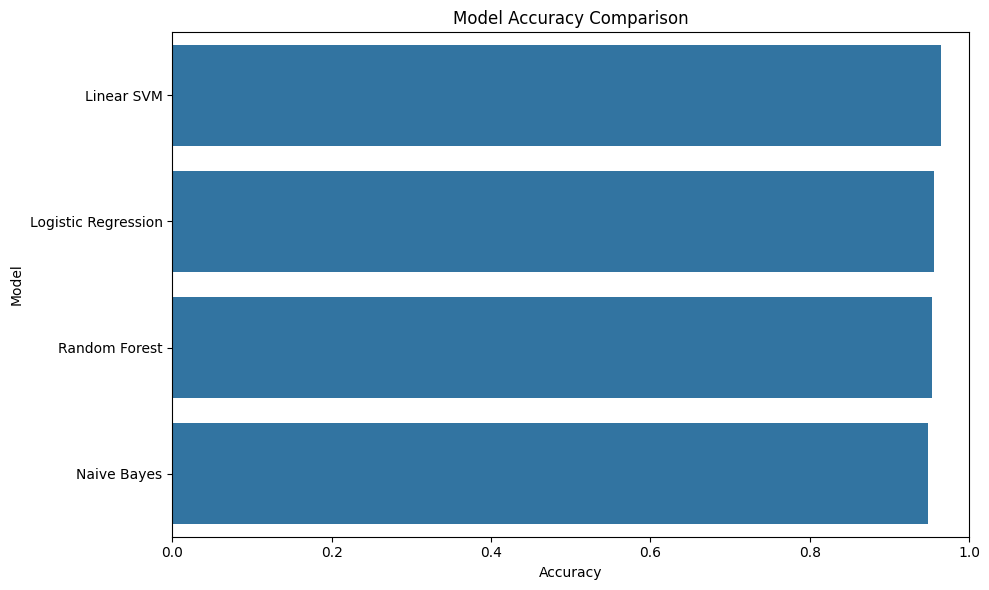

In [61]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model"
)

plt.xlim(0, 1)
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

##18. Model selection.

In [62]:
best_model_name = results_df.iloc[0]["Model"]
best_accuracy = results_df.iloc[0]["Accuracy"]

best_model = models[best_model_name]

print(f"Best model: {best_model_name}")
print(f"Accuracy: {best_accuracy:.4f}")

Best model: Linear SVM
Accuracy: 0.9650


##19. Confusion matrix for selected model.

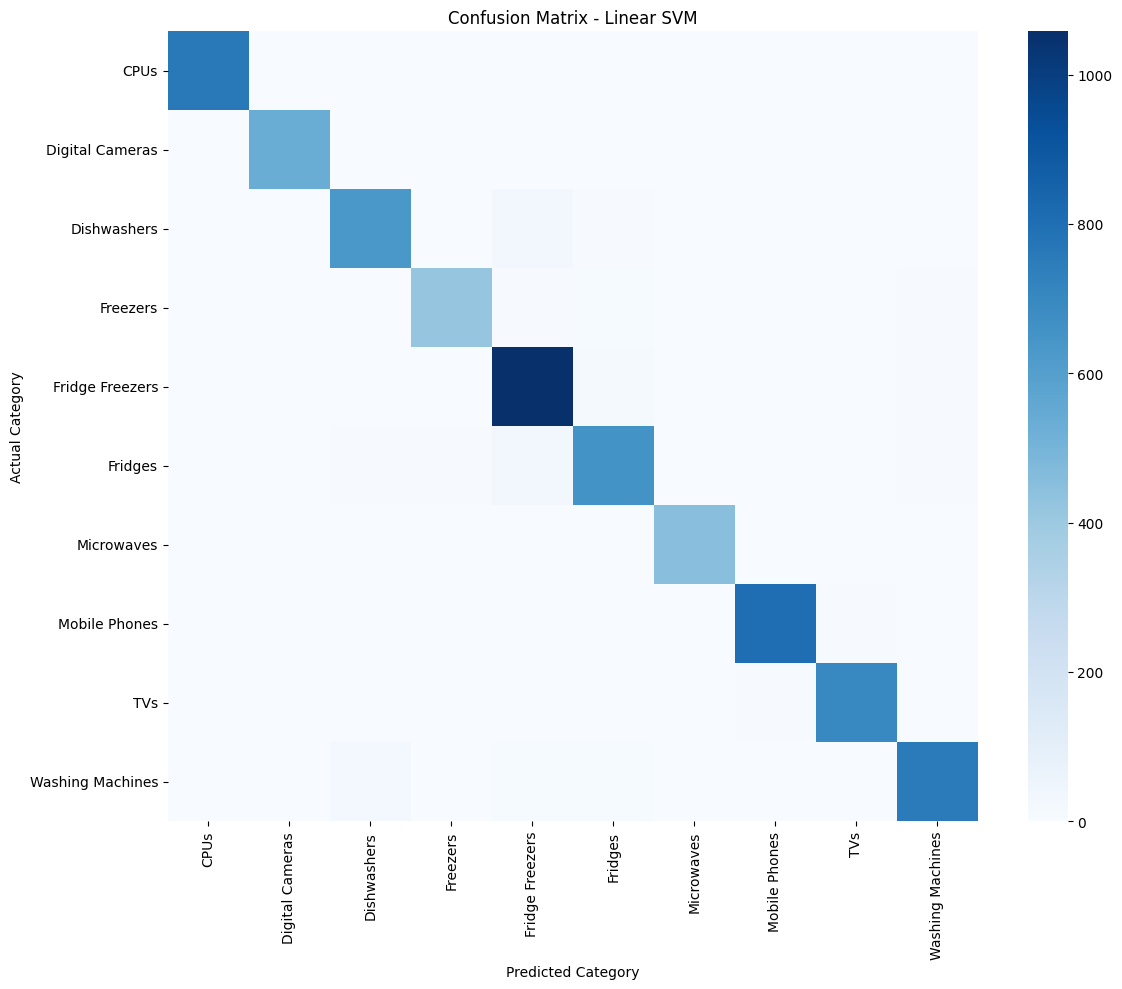

In [63]:
best_predictions = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=sorted(y_test.unique())
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.tight_layout()
plt.show()

##20.Final Classification report.

In [64]:
print(
    classification_report(
        y_test,
        best_predictions,
        zero_division=0
    )
)

                  precision    recall  f1-score   support

            CPUs       1.00      1.00      1.00       766
 Digital Cameras       1.00      0.99      1.00       538
     Dishwashers       0.95      0.93      0.94       681
        Freezers       0.97      0.95      0.96       440
 Fridge Freezers       0.92      0.97      0.94      1094
         Fridges       0.93      0.92      0.93       712
      Microwaves       0.98      0.97      0.98       466
   Mobile Phones       0.98      0.99      0.98       812
             TVs       0.98      0.99      0.99       708
Washing Machines       0.97      0.94      0.95       803

        accuracy                           0.96      7020
       macro avg       0.97      0.96      0.97      7020
    weighted avg       0.97      0.96      0.96      7020

